# Detección temprana de alertas MTA — Random Forest por línea

## Objetivo

Predecir si una línea de metro va a recibir una alerta oficial MTA en los **próximos 30 minutos**,
usando datos operativos (retrasos, headway, actualizaciones de estado) y contexto histórico de alertas.

**Target**: `alert_in_next_30m_max` — binario, 1 si hay alerta en la siguiente ventana de 30 min.

## Dataset de partida


Este parquet contiene la fusión de:
- **GTFS realtime**: retrasos por parada y trip (`delay_seconds`, `actual_headway_seconds`, ...)
- **Alertas MTA**: cuándo se emitieron, para qué línea y de qué categoría (Severe Delay, Suspension, Service Change, ...)
- **Meteorología** y **eventos** de la ciudad

Todo agrupado en ventanas de 30 minutos → ~21 millones de filas, **una por parada × ventana de 30 min**.

## Estrategia: agregar a nivel de línea

Las alertas MTA se emiten **por línea** (route_id), no por parada individual.
Por eso re-agregamos el dataset a nivel `route_id + direction + 30min` → ~755K filas.

Esto permite construir features que capturan el estado **global de la línea**:
porcentaje de paradas retrasadas, irregularidad del headway, aceleración del retraso, etc.

## Experimentos

| Exp | Descripción | PR-AUC |
|---|---|---|
| **1** | Por línea + `seg_desde_ultima_alerta_linea` | 0.708 |
| **2** | Por línea + categorías de alerta, **sin** tiempo desde última alerta | 0.451 |

Exp 1 es el modelo más honesto para detección temprana: no depende de si hubo una alerta reciente,
sino de señales operativas reales.

## 1) Imports y configuración

In [8]:
import os
import sys
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, recall_score, precision_score,
    precision_recall_curve
)

load_dotenv()

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet

print('Setup completado')

Setup completado


## 2) Carga del dataset desde MinIO

Cargamos el parquet de 30 minutos. Es el fichero central del proyecto:
fusión de GTFS realtime + alertas MTA + meteorología, agrupado en ventanas de 30 min.

- **Ruta MinIO**: `grupo5/aggregations/DataFrameGroupedByMin=30.parquet`
- **Tamaño**: ~21 millones de filas × 82 columnas
- **Granularidad**: una fila por parada (`stop_id`) × ventana de 30 minutos

In [10]:
ACCESS_KEY = os.environ['MINIO_ACCESS_KEY']
SECRET_KEY = os.environ['MINIO_SECRET_KEY']

PATH   = 'grupo5/aggregations/DataFrameGroupedByMin=30.parquet'
TARGET = 'alert_in_next_30m_max'

print('Cargando dataset desde MinIO...')
df_raw = download_df_parquet(ACCESS_KEY, SECRET_KEY, PATH)
print(f'Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
print(f'Positivos (alerta en siguientes 30 min): {df_raw[TARGET].mean()*100:.1f}%')

Cargando dataset desde MinIO...
Dataset cargado: 21,324,492 filas x 82 columnas
Positivos (alerta en siguientes 30 min): 18.3%


## 3) Agregación a nivel de línea

Re-agregamos el dataset de **parada** → **línea** (`route_id + direction + 30min`).

### ¿Por qué?

Las alertas MTA se emiten a nivel de línea, no de parada. Usar datos por parada añade ruido:
una parada puede estar retrasada sin que haya alerta en la línea, o viceversa.

Al agregar por línea obtenemos features que capturan el estado **global**:

| Feature | Significado |
|---|---|
| `pct_paradas_retrasadas` | % de paradas de la línea con retraso > 60s |
| `delay_std_linea` | Dispersión del retraso — si es alto, el problema no es uniforme |
| `headway_std_linea` | Irregularidad en el espaciado entre trenes |
| `delay_acceleration_linea` | Si el retraso medio está empeorando respecto a la ventana anterior |
| `category_*` | Categorías de alertas presentes en la ventana (Service Change, Delay, Suspension...) |
| `seg_desde_ultima_alerta_linea` | Segundos desde la alerta más reciente de cualquier parada de la línea |

In [12]:
# Detectar columnas de categoría de alerta disponibles en el parquet
cat_cols = [c for c in df_raw.columns if c.startswith('category_')]
print(f'Categorías de alerta encontradas: {cat_cols}')

# Seleccionar solo las columnas necesarias (evita copiar las 82 columnas en memoria)
COLS = [
    'route_id', 'direction', 'merge_time',
    'delay_seconds_mean', 'lagged_delay_1_mean', 'lagged_delay_2_mean',
    'delay_1_before', 'delay_2_before', 'delay_3_before',
    'actual_headway_seconds_mean', 'is_unscheduled_max',
    'num_updates_sum', 'match_key_nunique',
    'hour_sin_first', 'hour_cos_first', 'dow_first', 'is_weekend_max',
    'seconds_since_last_alert_mean',
    TARGET,
] + cat_cols
COLS = [c for c in COLS if c in df_raw.columns]

df_work = df_raw[COLS]
df_work = df_work[df_work[TARGET].notna()].copy()
df_work['merge_time'] = pd.to_datetime(df_work['merge_time'])
df_work[TARGET] = df_work[TARGET].astype(int)
df_work['parada_retrasada'] = (df_work['delay_seconds_mean'] > 60).astype(int)

print(f'Filas con target válido: {df_work.shape[0]:,}')

Categorías de alerta encontradas: ['category_Cancellation_sum', 'category_Delay_sum', 'category_Other_sum', 'category_Service Change_sum', 'category_Severe Delay_sum', 'category_Suspension_sum']
Filas con target válido: 21,324,492


In [13]:
# Agregar de parada → línea
agg_dict = {
    'delay_seconds_mean':          ['mean', 'max', 'std'],
    'parada_retrasada':            ['sum', 'count'],
    'lagged_delay_1_mean':         'mean',
    'lagged_delay_2_mean':         'mean',
    'delay_1_before':              'mean',
    'delay_2_before':              'mean',
    'delay_3_before':              'mean',
    'actual_headway_seconds_mean': ['mean', 'std'],
    'is_unscheduled_max':          'max',
    'num_updates_sum':             'sum',
    'match_key_nunique':           'sum',
    'hour_sin_first':              'first',
    'hour_cos_first':              'first',
    'dow_first':                   'first',
    'is_weekend_max':              'max',
    # min = la alerta más reciente de cualquier parada de la línea
    'seconds_since_last_alert_mean': 'min',
    TARGET: 'max',
}
for col in cat_cols:
    agg_dict[col] = 'max'  # ¿hubo al menos un evento de esta categoría en la línea?

print('Agregando por línea...')
df_linea = df_work.groupby(
    ['route_id', 'direction', pd.Grouper(key='merge_time', freq='30min')]
).agg(agg_dict).reset_index()

# Aplanar columnas multinivel generadas por las agregaciones dobles
df_linea.columns = [
    '_'.join(filter(None, col)) if isinstance(col, tuple) else col
    for col in df_linea.columns
]

df_linea = df_linea.rename(columns={
    'delay_seconds_mean_mean':           'delay_mean_linea',
    'delay_seconds_mean_max':            'delay_max_linea',
    'delay_seconds_mean_std':            'delay_std_linea',
    'parada_retrasada_sum':              'paradas_retrasadas',
    'parada_retrasada_count':            'total_paradas',
    'lagged_delay_1_mean_mean':          'lag1_mean_linea',
    'lagged_delay_2_mean_mean':          'lag2_mean_linea',
    'delay_1_before_mean':               'delay_1_before_mean',
    'delay_2_before_mean':               'delay_2_before_mean',
    'delay_3_before_mean':               'delay_3_before_mean',
    'actual_headway_seconds_mean_mean':  'headway_mean_linea',
    'actual_headway_seconds_mean_std':   'headway_std_linea',
    'is_unscheduled_max_max':            'is_unscheduled',
    'num_updates_sum_sum':               'num_updates',
    'match_key_nunique_sum':             'match_key_nunique',
    'hour_sin_first_first':              'hour_sin',
    'hour_cos_first_first':              'hour_cos',
    'dow_first_first':                   'dow',
    'is_weekend_max_max':                'is_weekend',
    'seconds_since_last_alert_mean_min': 'seg_desde_ultima_alerta_linea',
    f'{TARGET}_max':                     'alert_in_next_30m',
})

del df_work
gc.collect()

# Features derivadas
df_linea['pct_paradas_retrasadas']   = df_linea['paradas_retrasadas'] / df_linea['total_paradas'].clip(lower=1)
df_linea['delay_acceleration_linea'] = df_linea['delay_mean_linea'] - df_linea['lag1_mean_linea']

# Encoding de categóricas
for col in ['route_id', 'direction']:
    le = LabelEncoder()
    df_linea[col] = le.fit_transform(df_linea[col].astype(str).fillna('UNKNOWN'))

# NaN en historial de alertas → 999999 (no hubo alerta reciente)
df_linea['seg_desde_ultima_alerta_linea'] = df_linea['seg_desde_ultima_alerta_linea'].fillna(999999)

df_linea = df_linea.dropna(subset=['alert_in_next_30m'])
df_linea['alert_in_next_30m'] = df_linea['alert_in_next_30m'].astype(int)

print(f'Dataset por línea: {df_linea.shape[0]:,} filas x {df_linea.shape[1]} columnas')
print(f'Reducción: {df_raw.shape[0]:,} → {df_linea.shape[0]:,} filas')
print(f'Positivos: {df_linea["alert_in_next_30m"].mean()*100:.1f}%')

Agregando por línea...


C:\Users\david\AppData\Local\Temp\ipykernel_22076\2626967038.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_linea = df_work.groupby(


Dataset por línea: 755,443 filas x 32 columnas
Reducción: 21,324,492 → 755,443 filas
Positivos: 17.7%


## 4) División temporal y muestra de entrenamiento

Split temporal estricto para respetar la naturaleza de serie temporal:

- **Train**: primeros 70% de días → 10% muestreado para rapidez en experimentos
- **Val**: días 70%-85%
- **Test**: últimos 15% de días — evaluación final

Val y Test se usan completos para métricas representativas.

In [15]:
TARGET_LINEA = 'alert_in_next_30m'

df_linea = df_linea.sort_values('merge_time').reset_index(drop=True)
dias     = sorted(df_linea['merge_time'].dt.date.unique())
corte_70 = dias[int(len(dias) * 0.70)]
corte_85 = dias[int(len(dias) * 0.85)]

train = df_linea[df_linea['merge_time'].dt.date <  corte_70].sample(frac=0.10, random_state=42).copy()
val   = df_linea[(df_linea['merge_time'].dt.date >= corte_70) & (df_linea['merge_time'].dt.date < corte_85)].copy()
test  = df_linea[df_linea['merge_time'].dt.date >= corte_85].copy()

print(f'Train (10% muestra): {len(train):,} filas  — hasta {corte_70}')
print(f'Val   (completo):    {len(val):,} filas  — {corte_70} → {corte_85}')
print(f'Test  (completo):    {len(test):,} filas  — desde {corte_85}')
print(f'Positivos en test:  {test[TARGET_LINEA].mean()*100:.1f}%')

Train (10% muestra): 52,584 filas  — hasta 2025-09-22
Val   (completo):    113,632 filas  — 2025-09-22 → 2025-11-11
Test  (completo):    115,974 filas  — desde 2025-11-11
Positivos en test:  17.9%


## 5) Experimento D — por línea con historial de alertas

Versión completa: incluye `seg_desde_ultima_alerta_linea`
(segundos desde la alerta más reciente en cualquier parada de la línea).

**Por qué funciona bien**: las alertas tienden a aparecer en rachas.
Al medirlo a nivel de línea (mínimo de todas las paradas), la señal es limpia y coherente con
cómo publica el MTA sus alertas.

> ⚠️ Limitación: el modelo depende en parte de autocorrelación temporal
> (si hubo alerta → habrá otra). En producción es válido porque el MTA publica en tiempo real.

Experimento D: 29 features
Baseline PR-AUC: 0.1790
Modelo entrenado

RESULTADOS Experimento D:
  PR-AUC: 0.7085
  ROC-AUC: 0.8569
  F1: 0.6321
  Recall: 0.5319
  Precision: 0.7789
  Threshold: 0.6000


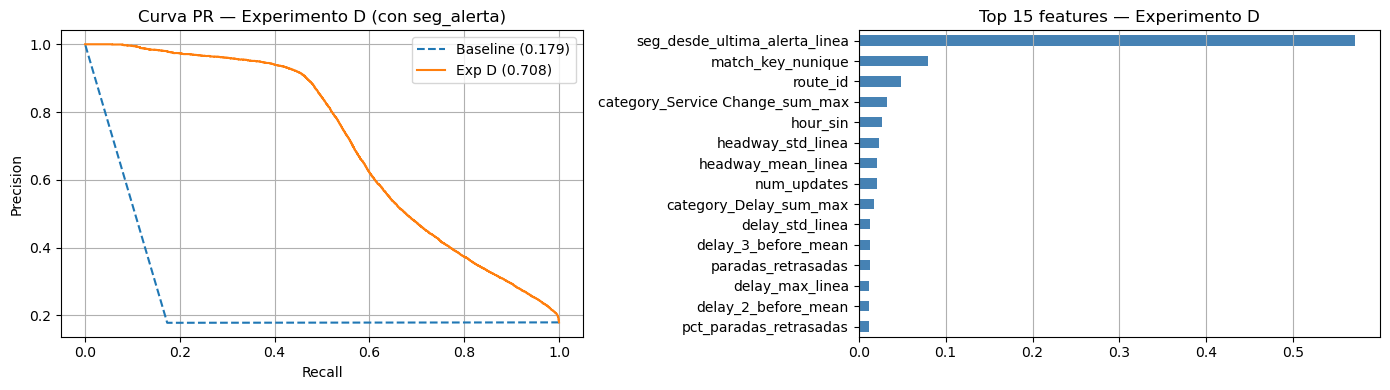

In [17]:
cat_cols_linea = [c for c in df_linea.columns if c.startswith('category_')]

FEATURES_D = [
    # Retraso global de la línea
    'delay_mean_linea', 'delay_max_linea', 'delay_std_linea',
    # Proporción de paradas afectadas
    'paradas_retrasadas', 'pct_paradas_retrasadas',
    # Evolución temporal del retraso
    'lag1_mean_linea', 'lag2_mean_linea',
    'delay_1_before_mean', 'delay_2_before_mean', 'delay_3_before_mean',
    # Tendencia: ¿el retraso está empeorando?
    'delay_acceleration_linea',
    # Irregularidad del servicio
    'headway_mean_linea', 'headway_std_linea',
    # Actividad operativa
    'is_unscheduled', 'num_updates', 'match_key_nunique',
    # Temporales
    'hour_sin', 'hour_cos', 'dow', 'is_weekend',
    # Identidad de la línea
    'route_id', 'direction',
    # Historial de alertas a nivel de línea
    'seg_desde_ultima_alerta_linea',
] + cat_cols_linea
FEATURES_D = [f for f in FEATURES_D if f in df_linea.columns]
print(f'Experimento D: {len(FEATURES_D)} features')

# Imputar NaN
for split in [train, val, test]:
    for col in FEATURES_D:
        if split[col].isna().any():
            split.loc[:, col] = split[col].fillna(split[col].median())

X_train_d, y_train_d = train[FEATURES_D], train[TARGET_LINEA]
X_test_d,  y_test_d  = test[FEATURES_D],  test[TARGET_LINEA]

# Baseline
baseline_d = DummyClassifier(strategy='stratified', random_state=42)
baseline_d.fit(X_train_d, y_train_d)
pr_base_d = average_precision_score(y_test_d, baseline_d.predict_proba(X_test_d)[:, 1])
print(f'Baseline PR-AUC: {pr_base_d:.4f}')

# Random Forest
rf_d = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_d.fit(X_train_d, y_train_d)
print('Modelo entrenado')

# Evaluación con threshold óptimo por F1
y_prob_d   = rf_d.predict_proba(X_test_d)[:, 1]
thresholds = np.arange(0.05, 0.95, 0.01)
f1s_d      = [f1_score(y_test_d, (y_prob_d >= t).astype(int), zero_division=0) for t in thresholds]
thr_d      = thresholds[np.argmax(f1s_d)]
y_pred_d   = (y_prob_d >= thr_d).astype(int)

metricas_D = {
    'PR-AUC':    average_precision_score(y_test_d, y_prob_d),
    'ROC-AUC':   roc_auc_score(y_test_d, y_prob_d),
    'F1':        f1_score(y_test_d, y_pred_d, zero_division=0),
    'Recall':    recall_score(y_test_d, y_pred_d, zero_division=0),
    'Precision': precision_score(y_test_d, y_pred_d, zero_division=0),
    'Threshold': thr_d,
}
print('\nRESULTADOS Experimento D:')
for k, v in metricas_D.items():
    print(f'  {k}: {v:.4f}')

# Gráficas
importancias_D = pd.Series(rf_d.feature_importances_, index=FEATURES_D).sort_values(ascending=False)
prec_base_d, rec_base_d, _ = precision_recall_curve(y_test_d, baseline_d.predict_proba(X_test_d)[:, 1])
prec_d, rec_d, _ = precision_recall_curve(y_test_d, y_prob_d)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rec_base_d, prec_base_d, linestyle='--', label=f'Baseline ({pr_base_d:.3f})')
axes[0].plot(rec_d, prec_d, label=f'Exp D ({metricas_D["PR-AUC"]:.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva PR — Experimento D (con seg_alerta)')
axes[0].legend(); axes[0].grid(True)
importancias_D.head(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 features — Experimento D')
axes[1].grid(True, axis='x')
plt.tight_layout()
plt.show()

## 6) Experimento E — por línea sin tiempo desde última alerta

Igual que Exp D pero **eliminando `seg_desde_ultima_alerta_linea`**.

**Objetivo**: aislar la señal operativa pura. Si el modelo sigue prediciendo bien
sin saber cuándo fue la última alerta, significa que los patrones de retraso y servicio
son suficientes para anticipar alertas.

Las features que más aportan en este caso son:
- `match_key_nunique` → número de trenes activos en la línea (congestión)
- `headway_std_linea` → irregularidad entre trenes (señal clásica de problema)
- `category_Service Change` / `category_Delay` → tipo de disrupciones previas en la línea
- `route_id` → algunas líneas (A, 1, 7...) son sistemáticamente más propensas a alertas

Experimento E: 28 features (Exp D tenía 29)
Feature eliminada: seg_desde_ultima_alerta_linea
Baseline PR-AUC: 0.1790
Modelo entrenado

RESULTADOS Experimento E:
  PR-AUC: 0.4506
  ROC-AUC: 0.7408
  F1: 0.4185
  Recall: 0.5661
  Precision: 0.3319
  Threshold: 0.5500


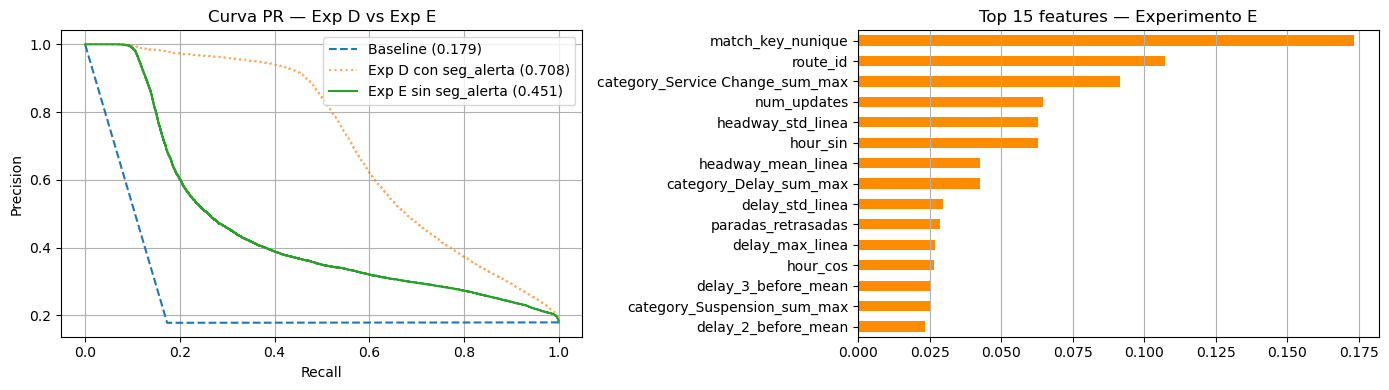


Impacto de seg_desde_ultima_alerta_linea: 0.2579 puntos de PR-AUC
  → 36.4% de la señal total de Exp D es autocorrelación


In [19]:
# Mismo conjunto que D, sin seg_desde_ultima_alerta_linea
FEATURES_E = [f for f in FEATURES_D if f != 'seg_desde_ultima_alerta_linea']
print(f'Experimento E: {len(FEATURES_E)} features (Exp D tenía {len(FEATURES_D)})')
print('Feature eliminada: seg_desde_ultima_alerta_linea')

X_train_e, y_train_e = train[FEATURES_E], train[TARGET_LINEA]
X_test_e,  y_test_e  = test[FEATURES_E],  test[TARGET_LINEA]

# Baseline
baseline_e = DummyClassifier(strategy='stratified', random_state=42)
baseline_e.fit(X_train_e, y_train_e)
pr_base_e = average_precision_score(y_test_e, baseline_e.predict_proba(X_test_e)[:, 1])
print(f'Baseline PR-AUC: {pr_base_e:.4f}')

# Random Forest
rf_e = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_e.fit(X_train_e, y_train_e)
print('Modelo entrenado')

y_prob_e = rf_e.predict_proba(X_test_e)[:, 1]
f1s_e    = [f1_score(y_test_e, (y_prob_e >= t).astype(int), zero_division=0) for t in thresholds]
thr_e    = thresholds[np.argmax(f1s_e)]
y_pred_e = (y_prob_e >= thr_e).astype(int)

metricas_E = {
    'PR-AUC':    average_precision_score(y_test_e, y_prob_e),
    'ROC-AUC':   roc_auc_score(y_test_e, y_prob_e),
    'F1':        f1_score(y_test_e, y_pred_e, zero_division=0),
    'Recall':    recall_score(y_test_e, y_pred_e, zero_division=0),
    'Precision': precision_score(y_test_e, y_pred_e, zero_division=0),
    'Threshold': thr_e,
}
print('\nRESULTADOS Experimento E:')
for k, v in metricas_E.items():
    print(f'  {k}: {v:.4f}')

# Gráficas: comparación directa D vs E
importancias_E = pd.Series(rf_e.feature_importances_, index=FEATURES_E).sort_values(ascending=False)
prec_e, rec_e, _ = precision_recall_curve(y_test_e, y_prob_e)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rec_base_d, prec_base_d, linestyle='--', label=f'Baseline ({pr_base_e:.3f})')
axes[0].plot(rec_d, prec_d, linestyle=':', alpha=0.7, label=f'Exp D con seg_alerta ({metricas_D["PR-AUC"]:.3f})')
axes[0].plot(rec_e, prec_e, label=f'Exp E sin seg_alerta ({metricas_E["PR-AUC"]:.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva PR — Exp D vs Exp E')
axes[0].legend(); axes[0].grid(True)
importancias_E.head(15).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 features — Experimento E')
axes[1].grid(True, axis='x')
plt.tight_layout()
plt.show()

diff = metricas_D['PR-AUC'] - metricas_E['PR-AUC']
print(f'\nImpacto de seg_desde_ultima_alerta_linea: {diff:.4f} puntos de PR-AUC')
print(f'  → {diff / metricas_D["PR-AUC"] * 100:.1f}% de la señal total de Exp D es autocorrelación')

## 7) Comparación y conclusiones

### Interpretación

- **Exp 1 (PR-AUC 0.708)**: modelo de máximo rendimiento. Válido en producción
  porque el MTA publica alertas en tiempo real y siempre sabemos cuándo fue la última.

- **Exp 2 (PR-AUC 0.451)**: modelo de detección temprana pura.
  Predice alertas basándose en condiciones operativas antes de que haya ninguna alerta reciente.

### ¿Qué mejoró respecto al modelo original (parada, PR-AUC 0.506)?

1. **Cambio de granularidad parada → línea**: las alertas son por línea, no por parada.
   Esto reduce el ruido y hace que cada fila sea coherente con el target.

2. **Nuevas features a nivel de línea**:
   - `pct_paradas_retrasadas` / `delay_std_linea`: qué porción de la línea está afectada
   - `headway_std_linea`: irregularidad del servicio
   - `delay_acceleration_linea`: si el problema está empeorando

3. **Categorías de alerta** (`category_Service Change`, `category_Delay`...):
   contexto sobre el tipo de disrupciones que tiene esta línea.

In [21]:
comparacion = pd.DataFrame({
    'D — línea + seg_alerta (máximo rendimiento)':         metricas_D,
    'E — línea + categorías, sin seg_alerta (detección)':  metricas_E,
}).T[['PR-AUC', 'ROC-AUC', 'F1', 'Recall', 'Precision', 'Threshold']].round(4)

print('COMPARACIÓN FINAL')
print('=' * 75)
print(comparacion.to_string())

diff = metricas_D['PR-AUC'] - metricas_E['PR-AUC']
print(f'\nSeñal de autocorrelación (D - E):  {diff:.4f} PR-AUC')
print(f'Señal operativa pura (E - baseline): {metricas_E["PR-AUC"] - pr_base_e:.4f} PR-AUC')

COMPARACIÓN FINAL
                                                    PR-AUC  ROC-AUC      F1  Recall  Precision  Threshold
D — línea + seg_alerta (máximo rendimiento)         0.7085   0.8569  0.6321  0.5319     0.7789       0.60
E — línea + categorías, sin seg_alerta (detección)  0.4506   0.7408  0.4185  0.5661     0.3319       0.55

Señal de autocorrelación (D - E):  0.2579 PR-AUC
Señal operativa pura (E - baseline): 0.2716 PR-AUC


## 8) Búsqueda de hiperparámetros — Optuna y Random Search

Optimizamos los hiperparámetros de **ambos experimentos** (1 y 2).

**Estrategia**:
- Cada combinación se evalúa en **validación** (test solo para el modelo final)
- El entrenamiento usa una **muestra del 5% del train** (~26K filas) para rapidez
- Métrica objetivo: **PR-AUC en validación**

**Hiperparámetros a buscar**:

| Parámetro | Rango | Impacto |
|---|---|---|
| `n_estimators` | 100 – 500 | Más árboles = más estable, pero más lento |
| `max_depth` | 5 – 25 | Profundidad del árbol, controla overfitting |
| `min_samples_split` | 2 – 20 | Mínimo de muestras para dividir un nodo |
| `min_samples_leaf` | 1 – 10 | Mínimo de muestras en hoja |
| `max_features` | sqrt, log2, 0.3, 0.5 | Nº de features consideradas en cada split |
| `class_weight` | balanced, balanced_subsample | Cómo compensar el desbalance de clases |

In [46]:
# Preparación común para ambas búsquedas
# Usamos val para evaluar cada combinación (test solo para el modelo final)

SAMPLE_BUSQUEDA = 1  # 5% del train

train_search = train.sample(frac=SAMPLE_BUSQUEDA, random_state=42)

# Exp D
X_search_d, y_search_d = train_search[FEATURES_D], train_search[TARGET_LINEA]
X_val_d = val[FEATURES_D].copy()
for col in FEATURES_D:
    if X_val_d[col].isna().any():
        X_val_d.loc[:, col] = X_val_d[col].fillna(X_val_d[col].median())

# Exp E
X_search_e, y_search_e = train_search[FEATURES_E], train_search[TARGET_LINEA]
X_val_e = val[FEATURES_E].copy()
for col in FEATURES_E:
    if X_val_e[col].isna().any():
        X_val_e.loc[:, col] = X_val_e[col].fillna(X_val_e[col].median())

y_val = val[TARGET_LINEA]

print(f'Train búsqueda: {len(train_search):,} filas')
print(f'Val evaluación: {len(val):,} filas')
print('Listo para búsqueda de hiperparámetros')

Train búsqueda: 52,584 filas
Val evaluación: 113,632 filas
Listo para búsqueda de hiperparámetros


### 8a) Optuna — búsqueda bayesiana

Optuna no prueba combinaciones al azar: aprende de los resultados anteriores para dirigir
la búsqueda hacia zonas prometedoras del espacio de hiperparámetros.

In [49]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS_OPTUNA = 20

def run_optuna(nombre, X_search, y_search, X_val, y_val):
    resultados = []

    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
            'max_depth':         trial.suggest_int('max_depth', 5, 25),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
            'class_weight':      trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
            'random_state': 42, 'n_jobs': -1,
        }
        rf = RandomForestClassifier(**params)
        rf.fit(X_search, y_search)
        pr_auc = average_precision_score(y_val, rf.predict_proba(X_val)[:, 1])
        resultados.append({'trial': trial.number + 1, 'pr_auc_val': pr_auc, **params})
        print(f'  [{nombre}] Trial {trial.number+1:02d}/{N_TRIALS_OPTUNA} | '
              f'PR-AUC val: {pr_auc:.4f} | depth={params["max_depth"]} '
              f'trees={params["n_estimators"]} features={params["max_features"]}')
        return pr_auc

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=False)

    best = study.best_params
    best['random_state'] = 42
    best['n_jobs'] = -1
    df = pd.DataFrame(resultados).sort_values('pr_auc_val', ascending=False)
    return study.best_value, best, df

print(f'=== Optuna Exp D ({N_TRIALS_OPTUNA} trials) ===')
best_val_optuna_d, best_params_optuna_d, df_optuna_d = run_optuna(
    'Exp D', X_search_d, y_search_d, X_val_d, y_val)
print(f'\nMejor PR-AUC val Exp D: {best_val_optuna_d:.4f}')

print(f'\n=== Optuna Exp E ({N_TRIALS_OPTUNA} trials) ===')
best_val_optuna_e, best_params_optuna_e, df_optuna_e = run_optuna(
    'Exp E', X_search_e, y_search_e, X_val_e, y_val)
print(f'\nMejor PR-AUC val Exp E: {best_val_optuna_e:.4f}')

print('\nTop 3 Exp D:')
print(df_optuna_d[['trial','pr_auc_val','n_estimators','max_depth','max_features']].head(3).to_string(index=False))
print('\nTop 3 Exp E:')
print(df_optuna_e[['trial','pr_auc_val','n_estimators','max_depth','max_features']].head(3).to_string(index=False))

=== Optuna Exp D (20 trials) ===
  [Exp D] Trial 01/20 | PR-AUC val: 0.7151 | depth=24 trees=250 features=0.5
  [Exp D] Trial 02/20 | PR-AUC val: 0.7125 | depth=25 trees=108 features=0.5
  [Exp D] Trial 03/20 | PR-AUC val: 0.7034 | depth=7 trees=345 features=log2
  [Exp D] Trial 04/20 | PR-AUC val: 0.7106 | depth=8 trees=343 features=sqrt
  [Exp D] Trial 05/20 | PR-AUC val: 0.7130 | depth=15 trees=148 features=log2
  [Exp D] Trial 06/20 | PR-AUC val: 0.7140 | depth=21 trees=488 features=log2
  [Exp D] Trial 07/20 | PR-AUC val: 0.7168 | depth=10 trees=255 features=0.5
  [Exp D] Trial 08/20 | PR-AUC val: 0.7172 | depth=9 trees=409 features=0.3
  [Exp D] Trial 09/20 | PR-AUC val: 0.7113 | depth=18 trees=446 features=0.3
  [Exp D] Trial 10/20 | PR-AUC val: 0.7142 | depth=19 trees=147 features=sqrt
  [Exp D] Trial 11/20 | PR-AUC val: 0.7177 | depth=12 trees=411 features=0.3
  [Exp D] Trial 12/20 | PR-AUC val: 0.7177 | depth=12 trees=411 features=0.3
  [Exp D] Trial 13/20 | PR-AUC val: 0.717

### 8b) Random Search — búsqueda aleatoria

Prueba combinaciones al azar dentro del espacio definido.
Sirve como comparación con Optuna: si dan resultados similares, el espacio está bien explorado.

In [51]:
from sklearn.model_selection import ParameterSampler

N_ITER_RANDOM = 20

param_grid = {
    'n_estimators':      [100, 150, 200, 300, 400, 500],
    'max_depth':         [5, 8, 10, 12, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf':  [1, 2, 3, 5, 8, 10],
    'max_features':      ['sqrt', 'log2', 0.3, 0.5],
    'class_weight':      ['balanced', 'balanced_subsample'],
}

def run_random_search(nombre, X_search, y_search, X_val, y_val):
    resultados = []
    sampler = ParameterSampler(param_grid, n_iter=N_ITER_RANDOM, random_state=42)
    for i, params in enumerate(sampler, 1):
        params_rf = {**params, 'random_state': 42, 'n_jobs': -1}
        rf = RandomForestClassifier(**params_rf)
        rf.fit(X_search, y_search)
        pr_auc = average_precision_score(y_val, rf.predict_proba(X_val)[:, 1])
        resultados.append({'combinacion': i, 'pr_auc_val': pr_auc, **params})
        print(f'  [{nombre}] Comb {i:02d}/{N_ITER_RANDOM} | PR-AUC val: {pr_auc:.4f} | '
              f'depth={params["max_depth"]} trees={params["n_estimators"]} '
              f'features={params["max_features"]}')
    df = pd.DataFrame(resultados).sort_values('pr_auc_val', ascending=False)
    best = df.iloc[0][list(param_grid.keys())].to_dict()
    best['random_state'] = 42
    best['n_jobs'] = -1
    return df['pr_auc_val'].max(), best, df

print(f'=== Random Search Exp D ({N_ITER_RANDOM} combinaciones) ===')
best_val_random_d, best_params_random_d, df_random_d = run_random_search(
    'Exp D', X_search_d, y_search_d, X_val_d, y_val)
print(f'\nMejor PR-AUC val Exp D: {best_val_random_d:.4f}')

print(f'\n=== Random Search Exp E ({N_ITER_RANDOM} combinaciones) ===')
best_val_random_e, best_params_random_e, df_random_e = run_random_search(
    'Exp E', X_search_e, y_search_e, X_val_e, y_val)
print(f'\nMejor PR-AUC val Exp E: {best_val_random_e:.4f}')

print('\nTop 3 Exp D:')
print(df_random_d[['combinacion','pr_auc_val','n_estimators','max_depth','max_features']].head(3).to_string(index=False))
print('\nTop 3 Exp E:')
print(df_random_e[['combinacion','pr_auc_val','n_estimators','max_depth','max_features']].head(3).to_string(index=False))

=== Random Search Exp D (20 combinaciones) ===
  [Exp D] Comb 01/20 | PR-AUC val: 0.7142 | depth=12 trees=400 features=sqrt
  [Exp D] Comb 02/20 | PR-AUC val: 0.7098 | depth=8 trees=200 features=sqrt
  [Exp D] Comb 03/20 | PR-AUC val: 0.6882 | depth=5 trees=200 features=log2
  [Exp D] Comb 04/20 | PR-AUC val: 0.6968 | depth=5 trees=150 features=sqrt
  [Exp D] Comb 05/20 | PR-AUC val: 0.7106 | depth=5 trees=400 features=0.5
  [Exp D] Comb 06/20 | PR-AUC val: 0.7160 | depth=8 trees=150 features=0.3
  [Exp D] Comb 07/20 | PR-AUC val: 0.7062 | depth=5 trees=400 features=0.3
  [Exp D] Comb 08/20 | PR-AUC val: 0.7149 | depth=25 trees=400 features=sqrt
  [Exp D] Comb 09/20 | PR-AUC val: 0.7065 | depth=5 trees=400 features=0.3
  [Exp D] Comb 10/20 | PR-AUC val: 0.7116 | depth=15 trees=100 features=0.3
  [Exp D] Comb 11/20 | PR-AUC val: 0.7106 | depth=10 trees=500 features=log2
  [Exp D] Comb 12/20 | PR-AUC val: 0.7098 | depth=8 trees=150 features=sqrt
  [Exp D] Comb 13/20 | PR-AUC val: 0.7171 

## 9) Modelos finales — mejores hiperparámetros evaluados en test

Para cada experimento elegimos los mejores params entre Optuna y Random Search,
entrenamos sobre el **train completo** y evaluamos en **test**.


--- Exp D (con seg_alerta) ---
Método ganador: Optuna (PR-AUC val: 0.7177)
Parámetros: {'n_estimators': 411, 'max_depth': 12, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 0.3, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
Entrenando sobre train completo (52,584 filas)...
Resultados en test:
  PR-AUC: 0.7158
  ROC-AUC: 0.8591
  F1: 0.6347
  Recall: 0.5297
  Precision: 0.7917
  Threshold: 0.5900

--- Exp E (sin seg_alerta) ---
Método ganador: Random Search (PR-AUC val: 0.4461)
Parámetros: {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_features': 0.3, 'class_weight': 'balanced_subsample', 'random_state': 42, 'n_jobs': -1}
Entrenando sobre train completo (52,584 filas)...
Resultados en test:
  PR-AUC: 0.4566
  ROC-AUC: 0.7452
  F1: 0.4202
  Recall: 0.6061
  Precision: 0.3216
  Threshold: 0.5400


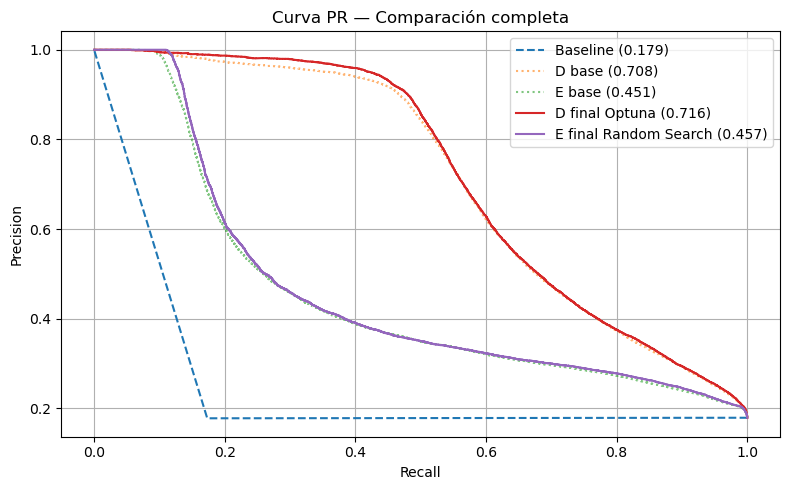

In [53]:
def entrenar_final(nombre, features, best_val_optuna, best_params_optuna,
                   best_val_random, best_params_random):
    if best_val_optuna >= best_val_random:
        best_params = best_params_optuna
        metodo = 'Optuna'
        mejor_val = best_val_optuna
    else:
        best_params = best_params_random
        metodo = 'Random Search'
        mejor_val = best_val_random

    print(f'\n--- {nombre} ---')
    print(f'Método ganador: {metodo} (PR-AUC val: {mejor_val:.4f})')
    print(f'Parámetros: {best_params}')

    print(f'Entrenando sobre train completo ({len(train):,} filas)...')
    rf = RandomForestClassifier(**best_params)
    rf.fit(train[features], train[TARGET_LINEA])

    y_prob = rf.predict_proba(test[features])[:, 1]
    y_test  = test[TARGET_LINEA]
    f1s     = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
    thr     = thresholds[np.argmax(f1s)]
    y_pred  = (y_prob >= thr).astype(int)

    metricas = {
        'PR-AUC':    average_precision_score(y_test, y_prob),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Threshold': thr,
    }
    print('Resultados en test:')
    for k, v in metricas.items():
        print(f'  {k}: {v:.4f}')
    return metricas, rf, y_prob, metodo

metricas_final_d, rf_final_d, y_prob_final_d, metodo_d = entrenar_final(
    'Exp D (con seg_alerta)',
    FEATURES_D, best_val_optuna_d, best_params_optuna_d,
    best_val_random_d, best_params_random_d
)

metricas_final_e, rf_final_e, y_prob_final_e, metodo_e = entrenar_final(
    'Exp E (sin seg_alerta)',
    FEATURES_E, best_val_optuna_e, best_params_optuna_e,
    best_val_random_e, best_params_random_e
)

# Gráfica comparativa
y_test_final = test[TARGET_LINEA]
prec_fd, rec_fd, _ = precision_recall_curve(y_test_final, y_prob_final_d)
prec_fe, rec_fe, _ = precision_recall_curve(y_test_final, y_prob_final_e)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_base_d, prec_base_d, linestyle='--', label=f'Baseline ({pr_base_d:.3f})')
ax.plot(rec_d,  prec_d,  linestyle=':', alpha=0.6, label=f'D base ({metricas_D["PR-AUC"]:.3f})')
ax.plot(rec_e,  prec_e,  linestyle=':', alpha=0.6, label=f'E base ({metricas_E["PR-AUC"]:.3f})')
ax.plot(rec_fd, prec_fd, label=f'D final {metodo_d} ({metricas_final_d["PR-AUC"]:.3f})')
ax.plot(rec_fe, prec_fe, label=f'E final {metodo_e} ({metricas_final_e["PR-AUC"]:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curva PR — Comparación completa')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

In [54]:
resumen = pd.DataFrame({
    'D base (default)':             metricas_D,
    f'D final ({metodo_d})':        metricas_final_d,
    'E base (default)':             metricas_E,
    f'E final ({metodo_e})':        metricas_final_e,
}).T[['PR-AUC', 'ROC-AUC', 'F1', 'Recall', 'Precision']].round(4)

print('RESUMEN FINAL')
print('=' * 65)
print(resumen.to_string())

mejora_d = metricas_final_d['PR-AUC'] - metricas_D['PR-AUC']
mejora_e = metricas_final_e['PR-AUC'] - metricas_E['PR-AUC']
print(f'\nMejora por optimización Exp D: +{mejora_d:.4f} PR-AUC')
print(f'Mejora por optimización Exp E: +{mejora_e:.4f} PR-AUC')

RESUMEN FINAL
                         PR-AUC  ROC-AUC      F1  Recall  Precision
D base (default)         0.7085   0.8569  0.6321  0.5319     0.7789
D final (Optuna)         0.7158   0.8591  0.6347  0.5297     0.7917
E base (default)         0.4506   0.7408  0.4185  0.5661     0.3319
E final (Random Search)  0.4566   0.7452  0.4202  0.6061     0.3216

Mejora por optimización Exp D: +0.0074 PR-AUC
Mejora por optimización Exp E: +0.0060 PR-AUC
